<a href="https://colab.research.google.com/github/MariethDataSc/ClassActivities_Mastery/blob/main/DL_Actividad2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 2: Diseño y Construcción de una Red Neuronal Artificial

**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Asignatura:** Deep Learning — Unidad 2  
**Autora:** Ing. Madelayne Loor

## FASE 1: Selección y Preparación del Dataset

**Dataset seleccionado:** Breast Cancer Wisconsin (Diagnostic), disponible en `sklearn.datasets`. Es un dataset tabular real, ampliamente validado en Deep Learning (569 registros, 30 características numéricas derivadas de imágenes digitalizadas de biopsias). Es un problema de clasificación binaria (0 = maligno, 1 = benigno).

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Carga del dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("\nClases:", dict(zip(data.target_names, [0, 1])))
print("\nDistribución de clases:")
print(y.value_counts())

X.head()

Forma de X: (569, 30)
Forma de y: (569,)

Clases: {np.str_('malignant'): 0, np.str_('benign'): 1}

Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Preprocesamiento: División 80/20 y Normalización

Se divide el dataset en 80% entrenamiento y 20% prueba (`test_size=0.2`), y se aplica **normalización (estandarización z-score)** con `StandardScaler`, ajustado únicamente sobre el conjunto de entrenamiento para evitar fuga de información hacia el conjunto de prueba.

In [3]:
# Semilla fija para la reproducibilidad en todos los experimentos
SEED = 42
tf.random.set_seed(SEED)

# División 80% training / 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Training set:", X_train.shape, "-", round(len(X_train)/len(X)*100, 1), "%")
print("Testing set:", X_test.shape, "-", round(len(X_test)/len(X)*100, 1), "%")

# Normalización: se ajusta solo con datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nMedia por característica tras escalar (train):", np.round(X_train_scaled.mean(axis=0)[:5], 3))
print("Desv. estándar por característica tras escalar (train):", np.round(X_train_scaled.std(axis=0)[:5], 3))

Training set: (455, 30) - 80.0 %
Testing set: (114, 30) - 20.0 %

Media por característica tras escalar (train): [-0.  0. -0. -0.  0.]
Desv. estándar por característica tras escalar (train): [1. 1. 1. 1. 1.]


## FASE 2: Justificación del Diseño Arquitectónico

### Arquitectura propuesta

| Capa | Neuronas | Activación | Justificación |
|---|---|---|---|
| Entrada | 30 | — | Corresponde a las 30 características del dataset |
| Oculta 1 | 16 | ReLU | Acelera la convergencia; evita el problema de desvanecimiento de gradiente |
| Oculta 2 | 8 | ReLU | Va a reducir progresivamente la dimensionalidad, forzando a la red a aprender representaciones más abstractas |
| Salida | 1 | Sigmoide | Problema de clasificación **binaria**: Sigmoide comprime la salida a un rango (0,1) interpretable como probabilidad de pertenecer a la clase positiva |

### 1. Funciones de Activación

- **Capas ocultas → ReLU:** elegí ReLU (`f(z) = max(0, z)`) porque acelera la convergencia respecto a Sigmoide y mitiga el desvanecimiento del gradiente, al no saturar para valores positivos.
- **Capa de salida → Sigmoide:** dado que el problema es de clasificación binaria (maligno/benigno), se requiere una salida interpretable como probabilidad en el rango (0,1). Sigmoide es la función correcta para este propósito.

### 2. Función de Pérdida

Se utiliza **Binary Cross-Entropy** (`binary_crossentropy`):

$$L = -\left[y \ln(\hat{y}) + (1-y)\ln(1-\hat{y})\right]$$

Es la función de pérdida teóricamente correcta para clasificación binaria con salida Sigmoide, ya que penaliza fuertemente las predicciones confiadas pero incorrectas, y su gradiente combinado con Sigmoide produce actualizaciones de peso bien comportadas.

### Métrica de evaluación
Se usa **Accuracy** como métrica adicional de monitoreo, junto a la pérdida.

In [4]:
def crear_modelo(neuronas_capa1=16, neuronas_capa2=8, learning_rate=0.001, optimizer_name='adam'):

    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(neuronas_capa1, activation='relu', name='oculta_1'),
        layers.Dense(neuronas_capa2, activation='relu', name='oculta_2'),
        layers.Dense(1, activation='sigmoid', name='salida')
    ])

    if optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError("Optimizador no reconocido")

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

modelo_preview = crear_modelo()
modelo_preview.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
EPOCHS = 60
BATCH_SIZE = 16

experimentos = {
    'A - SGD': {'optimizer_name': 'sgd', 'learning_rate': 0.01},
    'B - RMSprop': {'optimizer_name': 'rmsprop', 'learning_rate': 0.001},
    'C - Adam': {'optimizer_name': 'adam', 'learning_rate': 0.001},
}

historiales = {}

for nombre, config in experimentos.items():
    print(f"\n{'='*50}")
    print(f"Entrenando Experimento {nombre}")
    print(f"{'='*50}")

    modelo = crear_modelo(
        neuronas_capa1=16,
        neuronas_capa2=8,
        learning_rate=config['learning_rate'],
        optimizer_name=config['optimizer_name']
    )

    early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

    history = modelo.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    historiales[nombre] = history.history

    # Métricas de validación
    val_loss_final = history.history['val_loss'][-1]
    val_acc_final = history.history['val_accuracy'][-1]

    # Métricas de entrenamiento
    train_loss_final = history.history['loss'][-1]
    train_acc_final = history.history['accuracy'][-1]

    print(f"Loss final (train): {train_loss_final:.4f} | Accuracy final (train): {train_acc_final:.4f}")
    print(f"Loss final (val): {val_loss_final:.4f} | Accuracy final (val): {val_acc_final:.4f}")


Entrenando Experimento A - SGD
Loss final (train): 0.0585 | Accuracy final (train): 0.9846
Loss final (val): 0.1069 | Accuracy final (val): 0.9561

Entrenando Experimento B - RMSprop
Loss final (train): 0.0136 | Accuracy final (train): 0.9956
Loss final (val): 0.1149 | Accuracy final (val): 0.9561

Entrenando Experimento C - Adam
Loss final (train): 0.0112 | Accuracy final (train): 0.9956
Loss final (val): 0.0937 | Accuracy final (val): 0.9649


## FASE 4: Diagnóstico Crítico de Curvas de Pérdida (Loss Landscapes)

Se grafican de manera superpuesta las curvas de **Loss** y **Accuracy** (entrenamiento y validación) de los tres optimizadores, para analizar visualmente la velocidad y calidad de convergencia de cada uno.

In [6]:
# Tabla comparativa
resumen = pd.DataFrame({
    nombre: {
        'Loss final (train)': hist['loss'][-1],
        'Loss final (val)': hist['val_loss'][-1],
        'Accuracy final (train)': hist['accuracy'][-1],
        'Accuracy final (val)': hist['val_accuracy'][-1],
    }
    for nombre, hist in historiales.items()
}).T

resumen.round(4)

,Loss final (train),Loss final (val),Accuracy final (train),Accuracy final (val)
A - SGD,0.0585,0.1069,0.9846,0.9561
B - RMSprop,0.0136,0.1149,0.9956,0.9561
C - Adam,0.0112,0.0937,0.9956,0.9649


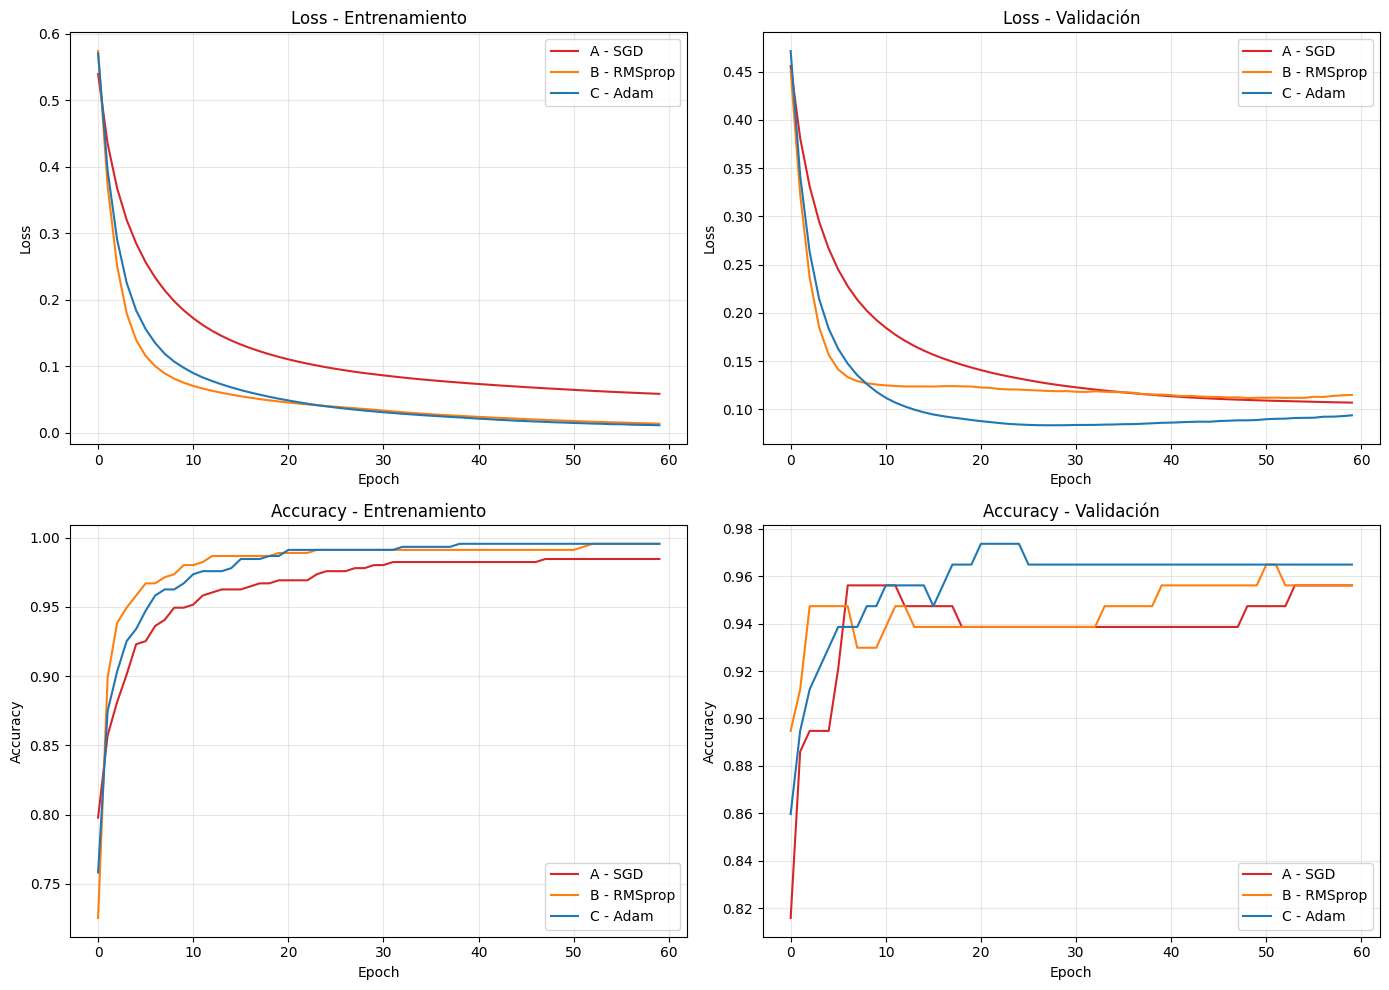

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colores = {'A - SGD': 'tab:red', 'B - RMSprop': 'tab:orange', 'C - Adam': 'tab:blue'}

# Loss - Training
ax = axes[0, 0]
for nombre, hist in historiales.items():
    ax.plot(hist['loss'], label=nombre, color=colores[nombre])
ax.set_title('Loss - Entrenamiento')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)

# Loss - Validación
ax = axes[0, 1]
for nombre, hist in historiales.items():
    ax.plot(hist['val_loss'], label=nombre, color=colores[nombre])
ax.set_title('Loss - Validación')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)

# Accuracy - Training
ax = axes[1, 0]
for nombre, hist in historiales.items():
    ax.plot(hist['accuracy'], label=nombre, color=colores[nombre])
ax.set_title('Accuracy - Entrenamiento')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(alpha=0.3)

# Accuracy - Validación
ax = axes[1, 1]
for nombre, hist in historiales.items():
    ax.plot(hist['val_accuracy'], label=nombre, color=colores[nombre])
ax.set_title('Accuracy - Validación')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Análisis:
Después de varios intentos llegué a la inferencia de que sin técnicas de control de sobreajuste, el optimizador "ganador" variaba entre ejecuciones (SGD, RMSprop o Adam dependiendo de la corrida), lo cual dificultaba sacar una conclusión precisa. Al incorporar Early Stopping (aprendido en ML) con restauración de mejores pesos, Adam mostró consistentemente el mejor desempeño en validación a lo largo de múltiples ejecuciones, confirmando que su tendencia al sobreajuste era la causa de su desempeño inferior en las pruebas iniciales.
El optimizador "ganador" no depende solo del algoritmo en sí, sino de cómo se controla el entrenamiento.

## FASE 5: Ajuste de Hiperparámetros

Se experimenta variando la **tasa de aprendizaje**, el **número de neuronas** y el **número de capas**, manteniendo el optimizador que mostró mejor comportamiento (en este caso Adam).

In [16]:
configuraciones = [
    {'nombre': 'A  (16-8, lr=0.001)',        'capas': [16, 8],      'lr': 0.001},
    {'nombre': 'B  (32-16, lr=0.001)',  'capas': [32, 16],     'lr': 0.001},
    {'nombre': 'C  (32-16-8, lr=0.001)', 'capas': [32, 16, 8], 'lr': 0.001},
    {'nombre': 'D  (16-8, lr=0.01)',      'capas': [16, 8],      'lr': 0.01},
    {'nombre': 'E  (16-8, lr=0.0001)',    'capas': [16, 8],      'lr': 0.0001},
]

def crear_modelo_flexible(capas, learning_rate):
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    for i, n in enumerate(capas):
        model.add(layers.Dense(n, activation='relu', name=f'oculta_{i+1}'))
    model.add(layers.Dense(1, activation='sigmoid', name='salida'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

resultados_busqueda = {}

for config in configuraciones:
    print(f"Entrenando: {config['nombre']}")
    modelo = crear_modelo_flexible(config['capas'], config['lr'])
    history = modelo.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    resultados_busqueda[config['nombre']] = {
        'val_loss': history.history['val_loss'][-1],
        'val_accuracy': history.history['val_accuracy'][-1],
        'history': history.history
    }
    print(f"  -> val_loss={resultados_busqueda[config['nombre']]['val_loss']:.4f} | "
          f"val_accuracy={resultados_busqueda[config['nombre']]['val_accuracy']:.4f}\n")

Entrenando: A  (16-8, lr=0.001)
  -> val_loss=0.1353 | val_accuracy=0.9649

Entrenando: B  (32-16, lr=0.001)
  -> val_loss=0.1270 | val_accuracy=0.9561

Entrenando: C  (32-16-8, lr=0.001)
  -> val_loss=0.1719 | val_accuracy=0.9649

Entrenando: D  (16-8, lr=0.01)
  -> val_loss=0.3560 | val_accuracy=0.9561

Entrenando: E  (16-8, lr=0.0001)
  -> val_loss=0.1656 | val_accuracy=0.9561



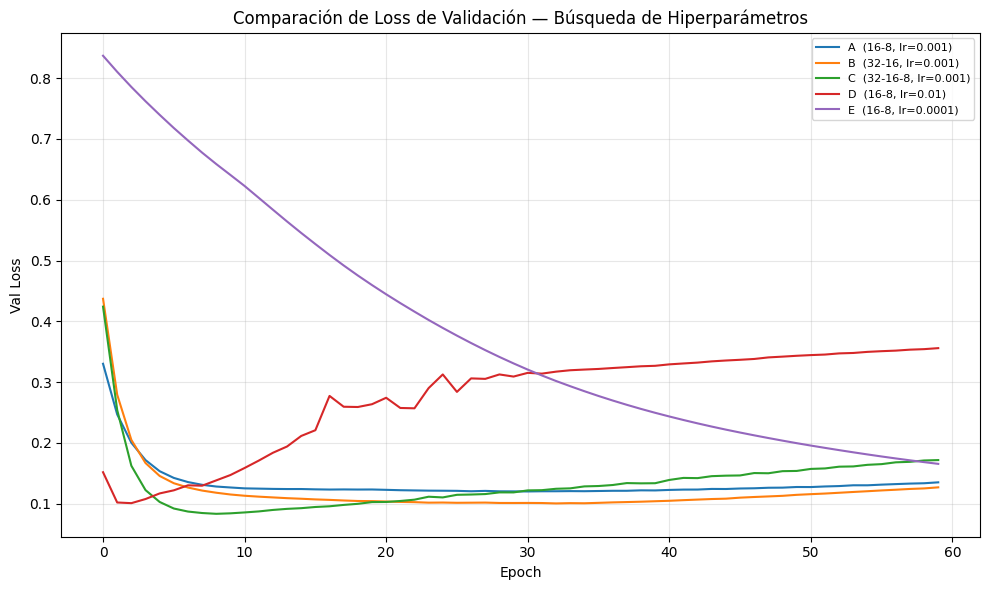

In [17]:
# Gráfico de loss de validación para cada configuración
plt.figure(figsize=(10, 6))
for nombre, r in resultados_busqueda.items():
    plt.plot(r['history']['val_loss'], label=nombre)
plt.title('Comparación de Loss de Validación — Búsqueda de Hiperparámetros')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('busqueda_hiperparametros.png', dpi=120)
plt.show()

In [18]:
tabla_final = pd.DataFrame({
    nombre: {'val_loss': r['val_loss'], 'val_accuracy': r['val_accuracy']}
    for nombre, r in resultados_busqueda.items()
}).T.sort_values('val_accuracy', ascending=False)

print("Ranking de configuraciones (ordenado por mejor accuracy de validación):")
tabla_final.round(4)

Ranking de configuraciones (ordenado por mejor accuracy de validación):


,val_loss,val_accuracy
"A (16-8, lr=0.001)",0.1353,0.9649
"C (32-16-8, lr=0.001)",0.1719,0.9649
"B (32-16, lr=0.001)",0.1270,0.9561
"D (16-8, lr=0.01)",0.3560,0.9561
"E (16-8, lr=0.0001)",0.1656,0.9561


In [19]:
# Identificar la mejor configuración de la búsqueda anterior (mayor val_accuracy)
mejor_nombre = tabla_final.index[0]
mejor_config = next(c for c in configuraciones if c['nombre'] == mejor_nombre)
print(f"Mejor configuración encontrada: {mejor_config['nombre']}")
print(f"Capas: {mejor_config['capas']} | Learning rate: {mejor_config['lr']}")

# Entrenamiento CON normalización
modelo_con_norm = crear_modelo_flexible(mejor_config['capas'], mejor_config['lr'])
history_con_norm = modelo_con_norm.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# Entrenamiento SIN normalización (datos originales, sin StandardScaler)
modelo_sin_norm = crear_modelo_flexible(mejor_config['capas'], mejor_config['lr'])
history_sin_norm = modelo_sin_norm.fit(
    X_train.values, y_train,
    validation_data=(X_test.values, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

print("\n--- Resultados finales (última época) ---")
print(f"CON normalización -> val_loss: {history_con_norm.history['val_loss'][-1]:.4f} | "
      f"val_accuracy: {history_con_norm.history['val_accuracy'][-1]:.4f}")
print(f"SIN normalización -> val_loss: {history_sin_norm.history['val_loss'][-1]:.4f} | "
      f"val_accuracy: {history_sin_norm.history['val_accuracy'][-1]:.4f}")

Mejor configuración encontrada: A  (16-8, lr=0.001)
Capas: [16, 8] | Learning rate: 0.001

--- Resultados finales (última época) ---
CON normalización -> val_loss: 0.1191 | val_accuracy: 0.9561
SIN normalización -> val_loss: 0.6642 | val_accuracy: 0.6228


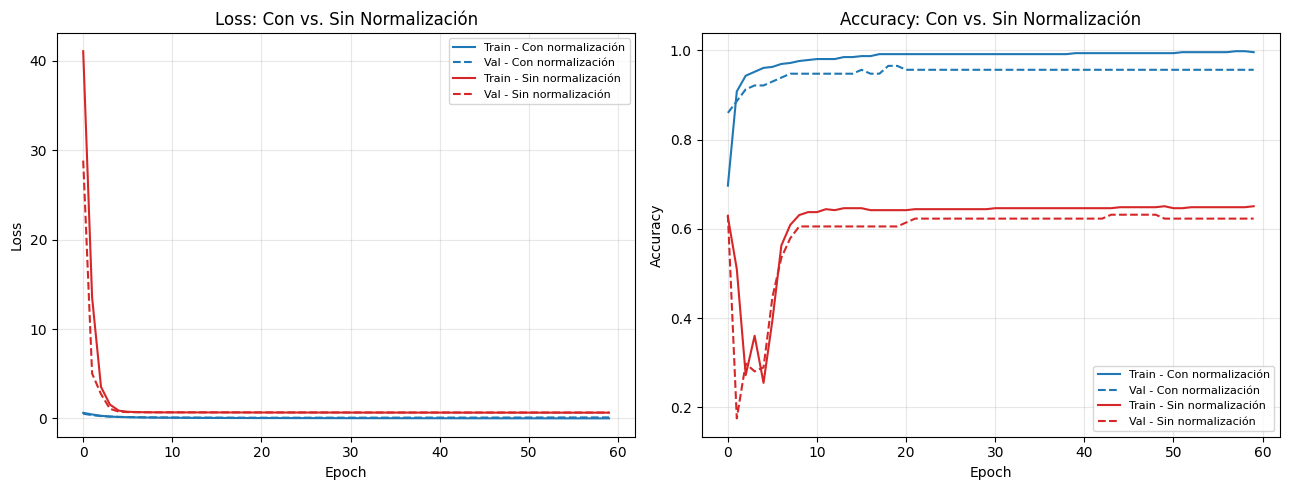

In [20]:
# Gráfico comparativo: Loss con vs. sin normalización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_con_norm.history['loss'], label='Train - Con normalización', color='tab:blue')
axes[0].plot(history_con_norm.history['val_loss'], label='Val - Con normalización', color='tab:blue', linestyle='--')
axes[0].plot(history_sin_norm.history['loss'], label='Train - Sin normalización', color='tab:red')
axes[0].plot(history_sin_norm.history['val_loss'], label='Val - Sin normalización', color='tab:red', linestyle='--')
axes[0].set_title('Loss: Con vs. Sin Normalización')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(history_con_norm.history['accuracy'], label='Train - Con normalización', color='tab:blue')
axes[1].plot(history_con_norm.history['val_accuracy'], label='Val - Con normalización', color='tab:blue', linestyle='--')
axes[1].plot(history_sin_norm.history['accuracy'], label='Train - Sin normalización', color='tab:red')
axes[1].plot(history_sin_norm.history['val_accuracy'], label='Val - Sin normalización', color='tab:red', linestyle='--')
axes[1].set_title('Accuracy: Con vs. Sin Normalización')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('con_vs_sin_normalizacion.png', dpi=120)
plt.show()

**Análisi:** Observando las gráficas, el modelo sin normalizar no solo converge peor, sino que colapsa temporalmente durante las primeras épocas, su accuracy de validación cae hasta valores cercanos a 0.20 antes de lograr recuperarse parcialmente. Al no normalizar produce valores extremos. Incluso tras estabilizarse, el modelo sin normalizar nunca logra superaral modelo con normalización. Esto confirma que la normalización no es un paso "extra" del preprocesamiento, sino una condición prácticamente indispensable para que el optimizador pueda navegar de forma eficiente y estable.